In [7]:
import os
import sys
import time
import datetime
import pickle
import numpy as np
import pandas as pd

src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

from pytensor.graph.op import Op
from pytensor.link.jax.dispatch import jax_funcify
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

from efficient_fpt_jax.multi_stage import get_addm_fptd_jax_fast, pad_sacc_array_safely

## Load Datasets

In [8]:
monk_data_1 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/empirical_data/behav_table_1.csv")
monk_data_2 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/empirical_data/behav_table_2.csv")
monk_data_3 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/empirical_data/behav_table_3.csv")

print(f"Monkey 1: {len(monk_data_1)} trials")
print(f"Monkey 2: {len(monk_data_2)} trials")
print(f"Monkey 3: {len(monk_data_3)} trials")

Monkey 1: 587 trials
Monkey 2: 607 trials
Monkey 3: 606 trials


In [9]:
monk_data_1.sort_values(by="trialNum", ascending=True)

,trialNum,lVal,rVal,firstVal,secondVal,chosenVal,leftChosen,firstChosen,liftRT,reachRT,firstIsLeft,firstIsRight,secondIsLeft,secondIsRight,firstFixLat,secondFixLat,thirdFixLat,firstFixDur,secondFixDur,thirdFixDur
308,1,3,1,3,1,1,0,0,0.757170,0.172254,1,0,0,1,0.162,0.410,NaN,0.188,0.644,NaN
412,2,4,3,4,3,4,1,1,0.747137,0.150739,1,0,0,1,0.168,0.420,0.636,0.192,0.156,0.576
153,3,2,4,2,4,4,0,0,0.747201,0.151524,1,0,0,1,0.134,0.402,NaN,0.212,0.916,NaN
361,4,3,3,3,3,3,1,1,0.947236,0.141216,1,0,0,1,0.158,0.386,0.758,0.176,0.328,0.688
525,5,5,5,5,5,5,0,1,1.076900,0.164868,0,1,1,0,0.142,0.370,0.882,0.188,0.456,0.656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,583,4,2,2,4,4,1,0,0.777188,0.174139,0,1,1,0,0.171,0.423,NaN,0.208,0.656,NaN
306,584,4,3,3,4,4,1,0,0.877214,0.154446,0,1,1,0,0.173,0.401,NaN,0.184,0.780,NaN
411,585,2,3,3,2,3,0,1,1.027219,0.175890,0,1,1,0,0.117,0.405,0.765,0.228,0.316,0.552
307,586,3,4,3,4,4,0,0,0.867116,0.176373,1,0,0,1,0.149,0.417,NaN,0.220,1.048,NaN


In [10]:
max(monk_data_1['lVal'] - monk_data_1['rVal'])

4

## Global Configuration

In [11]:
sigma    = 1.0   # Fixed noise (unidentifiable with other params)
max_d    = 4    # Max fixation stages (padded saccade dimension)

TRUNC_NUM   = 6    # Series truncation (optimal for JAX/XLA)
N_DRAWS     = 500
N_TUNE      = 500
N_CHAINS    = 4
RANDOM_SEED = 42

## Helper Functions

In [12]:
def preprocess_monkey_data(df, max_d):
    """
    Transform a raw monkey-behaviour DataFrame into model-ready numpy arrays.

    Parameters
    ----------
    df : pd.DataFrame
        Raw behavioural table with columns: trialNum, lVal, rVal,
        firstFixLat, secondFixLat, thirdFixLat, firstIsLeft,
        liftRT, leftChosen.
    max_d : int
        Maximum number of fixation stages (width of padded saccade array).

    Returns
    -------
    dict with keys:
        r1, r2          : left / right value per trial
        rt              : reaction time relative to first fixation onset
        choice          : +1 (left chosen) / -1 (right chosen)
        flag_data       : 0 if first fixation is left, 1 if right
        sacc            : (n_trials, max_d) padded saccade-onset array
        length_data     : number of fixations per trial (2 or 3)
    """
    DATA_TYPE = np.float64
    df = df.sort_values(by='trialNum', ascending=True)

    r1 = df['lVal'].to_numpy(dtype=DATA_TYPE)
    r2 = df['rVal'].to_numpy(dtype=DATA_TYPE)

    third_present = df['thirdFixLat'].notna().to_numpy()
    length_data = np.where(third_present, 3, 2).astype(np.int32)

    t0 = df["firstFixLat"].to_numpy(dtype=DATA_TYPE)
    t1 = df["secondFixLat"].to_numpy(dtype=DATA_TYPE)
    t2 = df["thirdFixLat"].fillna(0).to_numpy(dtype=DATA_TYPE)

    sacc = np.zeros((len(df), max_d), dtype=DATA_TYPE)
    sacc[:, 0] = 0.0
    sacc[:, 1] = t1 - t0
    sacc[third_present, 2] = t2[third_present] - t0[third_present]

    first_is_left = df['firstIsLeft'].to_numpy().astype(int)
    flag_data = np.where(first_is_left == 1, 0, 1).astype(np.int32)

    rt_raw = df["liftRT"].to_numpy(dtype=DATA_TYPE)
    rt = rt_raw - t0 - 0.1 

    left_chosen = df["leftChosen"].to_numpy().astype(int)
    choice = np.where(left_chosen == 1, 1.0, -1.0).astype(np.int32)

    return dict(r1=r1, r2=r2, rt=rt, choice=choice,
                flag_data=flag_data, sacc=sacc, length_data=length_data)

# def preprocess_monkey_data(df, max_d):
#     """
#     Transform a raw monkey-behaviour DataFrame into model-ready numpy arrays.

#     Parameters
#     ----------
#     df : pd.DataFrame
#         Raw behavioural table with columns: trialNum, lVal, rVal,
#         firstFixLat, secondFixLat, thirdFixLat, firstIsLeft,
#         liftRT, leftChosen.
#     max_d : int
#         Maximum number of fixation stages (width of padded saccade array).

#     Returns
#     -------
#     dict with keys:
#         r1, r2          : left / right value per trial
#         rt              : reaction time relative to first fixation onset
#         choice          : +1 (left chosen) / -1 (right chosen)
#         flag_data       : 0 if first fixation is left, 1 if right
#         sacc            : (n_trials, max_d) padded saccade-onset array
#         length_data     : number of fixations per trial (2 or 3)
#     """
#     DATA_TYPE = np.float64
#     df = df.sort_values(by='trialNum', ascending=True)

#     r1 = df['lVal'].to_numpy(dtype=DATA_TYPE)
#     r2 = df['rVal'].to_numpy(dtype=DATA_TYPE)

#     third_present = df['thirdFixLat'].notna().to_numpy()
#     length_data = np.where(third_present, 3, 2).astype(np.int32)

#     t0 = df["firstFixLat"].to_numpy(dtype=DATA_TYPE)
#     firstfixDur = df['firstFixDur'].to_numpy(dtype=DATA_TYPE)
#     secondfixDur = df['secondFixDur'].to_numpy(dtype=DATA_TYPE)

#     t1 = df["secondFixLat"].to_numpy(dtype=DATA_TYPE)
#     t2 = df["thirdFixLat"].fillna(0).to_numpy(dtype=DATA_TYPE)

#     sacc = np.zeros((len(df), max_d), dtype=DATA_TYPE)
#     sacc[:, 0] = 0.0
#     sacc[:, 1] = firstfixDur
#     sacc[third_present, 2] = firstfixDur[third_present] + secondfixDur[third_present]

#     first_is_left = df['firstIsLeft'].to_numpy().astype(int)
#     flag_data = np.where(first_is_left == 1, 0, 1).astype(np.int32)

#     rt_raw = df["liftRT"].to_numpy(dtype=DATA_TYPE)
#     rt = rt_raw # dont subtract by first fixation here

#     left_chosen = df["leftChosen"].to_numpy().astype(int)
#     choice = np.where(left_chosen == 1, 1.0, -1.0).astype(np.int32)

#     return dict(r1=r1, r2=r2, rt=rt, choice=choice,
#                 flag_data=flag_data, sacc=sacc, length_data=length_data)

In [13]:
def make_jax_arrays(data, max_d):
    """
    Convert preprocessed numpy dict to JAX arrays and pre-compute
    safe saccade arrays (prevents NaN gradients at boundary).

    Parameters
    ----------
    data  : dict returned by preprocess_monkey_data
    max_d : int  (must match the value used during preprocessing)

    Returns
    -------
    dict of JAX arrays: rt, choice, d, r1, r2, flag, sacc_safe
    """
    jax_sacc = jnp.array(data['sacc'])
    jax_d    = jnp.array(data['length_data'])
    jax_sacc_safe = vmap(
        lambda s, d: pad_sacc_array_safely(s, d, max_d)
    )(jax_sacc, jax_d)

    return dict(
        rt       = jnp.array(data['rt']),
        choice   = jnp.array(data['choice']),
        d        = jax_d,
        r1       = jnp.array(data['r1']),
        r2       = jnp.array(data['r2']),
        flag     = jnp.array(data['flag_data']),
        sacc_safe= jax_sacc_safe,
    )

## Dataset-Agnostic JAX Likelihood Helpers

In [14]:
def compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d):
    """
    Compute the alternating drift array for a single trial.

    flag=0 (first fixation left):  [mu1, mu2, mu1, mu2, ...]
    flag=1 (first fixation right): [mu2, mu1, mu2, mu1, ...]
    """
    mu1 = kappa * (r1 - eta * r2)
    mu2 = kappa * (eta * r1 - r2)
    indices = jnp.arange(max_d)
    return jnp.where((indices % 2) == flag, mu1, mu2)


def jax_loglik_single(rt, choice, d, r1, r2, flag, sacc_safe,
                      eta, kappa, a, b, x0, sigma, max_d, trunc_num):
    """Log-likelihood for a single trial."""
    mu_array = compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d)
    fptd = get_addm_fptd_jax_fast(
        rt, d, mu_array, sacc_safe, sigma, a, b, x0, choice,
        order=30, trunc_num=trunc_num, safe_sacc=sacc_safe
    )
    return jnp.log(jnp.maximum(fptd, 1e-30))

In [15]:
def make_jax_likelihood(jax_data, sigma, max_d, trunc_num):
    """
    Build and JIT-compile JAX log-likelihood and gradient functions
    closed over a specific dataset.

    Parameters
    ----------
    jax_data  : dict returned by make_jax_arrays
    sigma     : float  noise parameter (fixed)
    max_d     : int    saccade array width
    trunc_num : int    series truncation number

    Returns
    -------
    loglik_jit   : jit-compiled total log-likelihood (eta, kappa, a, b, x0) -> scalar
    grad_loglik  : jit-compiled gradient tuple     (eta, kappa, a, b, x0) -> 5-tuple
    """
    def loglik_batch(eta, kappa, a, b, x0):
        per_trial = vmap(
            lambda rt, choice, d, r1, r2, flag, sacc_safe: jax_loglik_single(
                rt, choice, d, r1, r2, flag, sacc_safe,
                eta, kappa, a, b, x0, sigma, max_d, trunc_num
            )
        )
        logliks = per_trial(
            jax_data['rt'], jax_data['choice'], jax_data['d'],
            jax_data['r1'], jax_data['r2'], jax_data['flag'], jax_data['sacc_safe']
        )
        return jnp.sum(logliks)

    loglik_jit  = jit(loglik_batch)
    grad_loglik = jit(grad(loglik_batch, argnums=(0, 1, 2, 3, 4)))
    return loglik_jit, grad_loglik

## PyTensor Custom Ops (dataset-agnostic)

In [16]:
class LogLikeJAX(Op):
    """PyTensor Op wrapping a JAX likelihood with analytic gradients."""
    itypes = [pt.dvector]
    otypes = [pt.dscalar]

    def __init__(self, loglik_fn, grad_fn):
        self.loglik_fn = loglik_fn
        self.grad_fn   = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        outputs[0][0] = np.array(float(self.loglik_fn(eta, kappa, a, b, x0)),
                                 dtype="float64")

    def grad(self, inputs, output_grads):
        (theta,)  = inputs
        (g_out,)  = output_grads
        grads = LogLikeJAXGrad(self.grad_fn)(theta)
        return [g_out * grads]


class LogLikeJAXGrad(Op):
    """Gradient Op for LogLikeJAX."""
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, grad_fn):
        self.grad_fn = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        grads = self.grad_fn(eta, kappa, a, b, x0)
        outputs[0][0] = np.array([float(g) for g in grads], dtype="float64")


@jax_funcify.register(LogLikeJAX)
def jax_funcify_LogLikeJAX(op, **kwargs):
    loglik_fn = op.loglik_fn
    def loglik_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        return loglik_fn(eta, kappa, a, b, x0)
    return loglik_jax


@jax_funcify.register(LogLikeJAXGrad)
def jax_funcify_LogLikeJAXGrad(op, **kwargs):
    grad_fn = op.grad_fn
    def grad_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        return jnp.stack(grad_fn(eta, kappa, a, b, x0))
    return grad_jax

In [17]:
def make_pymc_model(loglike_op, M):
    """
    Construct a PyMC model with the custom JAX likelihood.

    Parameters
    ----------
    loglike_op : LogLikeJAX instance bound to a specific dataset
    M          : float  max observed RT (used to bound the collapse rate b)

    Returns
    -------
    pm.Model
    """
    with pm.Model() as model:
        eta     = pm.Beta("eta",   alpha=2.0, beta=2.0)
        kappa   = pm.Gamma("kappa", alpha=2.0, beta=4.0)
        a_param = pm.Gamma("a",     alpha=4.0, beta=2.0)

        b_raw   = pm.Beta("b_raw", alpha=2.0, beta=2.0)
        b_param = pm.Deterministic("b", b_raw * a_param / M * 0.95)

        x0_raw  = pm.Beta("x0_raw", alpha=2.0, beta=2.0)
        x0_param= pm.Deterministic("x0", -a_param + 2.0 * a_param * x0_raw)

        theta = pt.stack([eta, kappa, a_param, b_param, x0_param])
        pm.Potential("loglik", loglike_op(theta))
    return model

---
# Monkey 1

In [18]:
data_1     = preprocess_monkey_data(monk_data_1, max_d)
jax_data_1 = make_jax_arrays(data_1, max_d)

print(f"Monkey 1 | trials: {len(data_1['rt'])}, max RT: {data_1['rt'].max():.4f}")
print(f"JAX devices: {jax.devices()}")

Monkey 1 | trials: 587, max RT: 1.2751
JAX devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


In [19]:
data_1['sacc']

array([[0.   , 0.248, 0.   , 0.   ],
       [0.   , 0.252, 0.468, 0.   ],
       [0.   , 0.268, 0.   , 0.   ],
       ...,
       [0.   , 0.288, 0.648, 0.   ],
       [0.   , 0.268, 0.   , 0.   ],
       [0.   , 0.26 , 0.6  , 0.   ]], shape=(587, 4))

In [20]:
loglik_1, grad_1 = make_jax_likelihood(jax_data_1, sigma, max_d, TRUNC_NUM)

print("Warming up JIT for Monkey 1...")
t0_ = time.time()
ll_test_1 = loglik_1(0.7, 0.5, 2.0, 0.3, -0.2)
_          = grad_1(0.7, 0.5, 2.0, 0.3, -0.2)
print(f"JIT warm-up: {time.time()-t0_:.1f}s  |  ll={float(ll_test_1):.4f}")

op_1    = LogLikeJAX(loglik_1, grad_1)
model_1 = make_pymc_model(op_1, float(np.max(data_1['rt'])))
print("Model 1 built.", model_1.point_logps())

Warming up JIT for Monkey 1...
JIT warm-up: 6.4s  |  ll=-796.9836


/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Model 1 built. {'eta': np.float64(-0.98), 'kappa': np.float64(-0.61), 'a': np.float64(-0.25), 'b_raw': np.float64(-0.98), 'x0_raw': np.float64(-0.98), 'loglik': np.float64(-405.27)}


In [21]:
print(f"Sampling Monkey 1 | {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model_1:
    t_start = time.perf_counter()
    trace_1 = pm.sample(
        draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
    )
    t_sample_1 = time.perf_counter() - t_start

print(f"Finished: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total: {t_sample_1:.1f}s")

Sampling Monkey 1 | 500 draws, 500 tune, 4 chains
Started: 13:02:02


Compiling.. :   0%|          | 0/1000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/1000 [00:09<?, ?it/s]


Running chain 0:   5%|▌         | 50/1000 [00:14<01:31, 10.35it/s]


Running chain 0:  25%|██▌       | 250/1000 [00:29<00:44, 16.70it/s]


Running chain 0:  35%|███▌      | 350/1000 [00:32<00:29, 21.89it/s]


Running chain 0:  40%|████      | 400/1000 [00:34<00:24, 24.89it/s]


Running chain 0:  45%|████▌     | 450/1000 [00:35<00:19, 28.33it/s]


Running chain 0:  55%|█████▌    | 550/1000 [00:38<00:14, 30.40it/s]


Running chain 0:  60%|██████    | 600/1000 [00:40<00:12, 31.40it/s]


Running chain 0:  65%|██████▌   | 650/1000 [00:41<00:10, 33.32it/s]


Running chain 0:  70%|███████   | 700/1000 [00:43<00:09, 33.01it/s]

Running chain 0:  80%|████████  | 800/1000 [00:45<00:05, 34.81it/s]


Running chain 0:  85%|████████▌ | 850/1000 [00:47<00:04, 35.50it/s]


Running chain 0:  90%|█████████ | 900/1000 [00:48<00:02, 34.61it/s]


Running chain 0:  95%|█████████▌| 950/1000

Finished: 13:03:07
Total: 65.0s


In [22]:
params = ['eta', 'kappa', 'a', 'b', 'x0']

=== Monkey 1 Diagnostics ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.168  0.032   0.103    0.227      0.001    0.001    1956.0    1080.0   
kappa  1.098  0.042   1.026    1.181      0.001    0.001    1495.0    1447.0   
a      2.235  0.058   2.124    2.341      0.001    0.001    1582.0    1456.0   
b      1.657  0.044   1.575    1.738      0.001    0.001    1623.0    1386.0   
x0     0.056  0.030  -0.001    0.112      0.001    0.001    2152.0    1170.0   

       r_hat  
eta      1.0  
kappa    1.0  
a        1.0  
b        1.0  
x0       1.0  


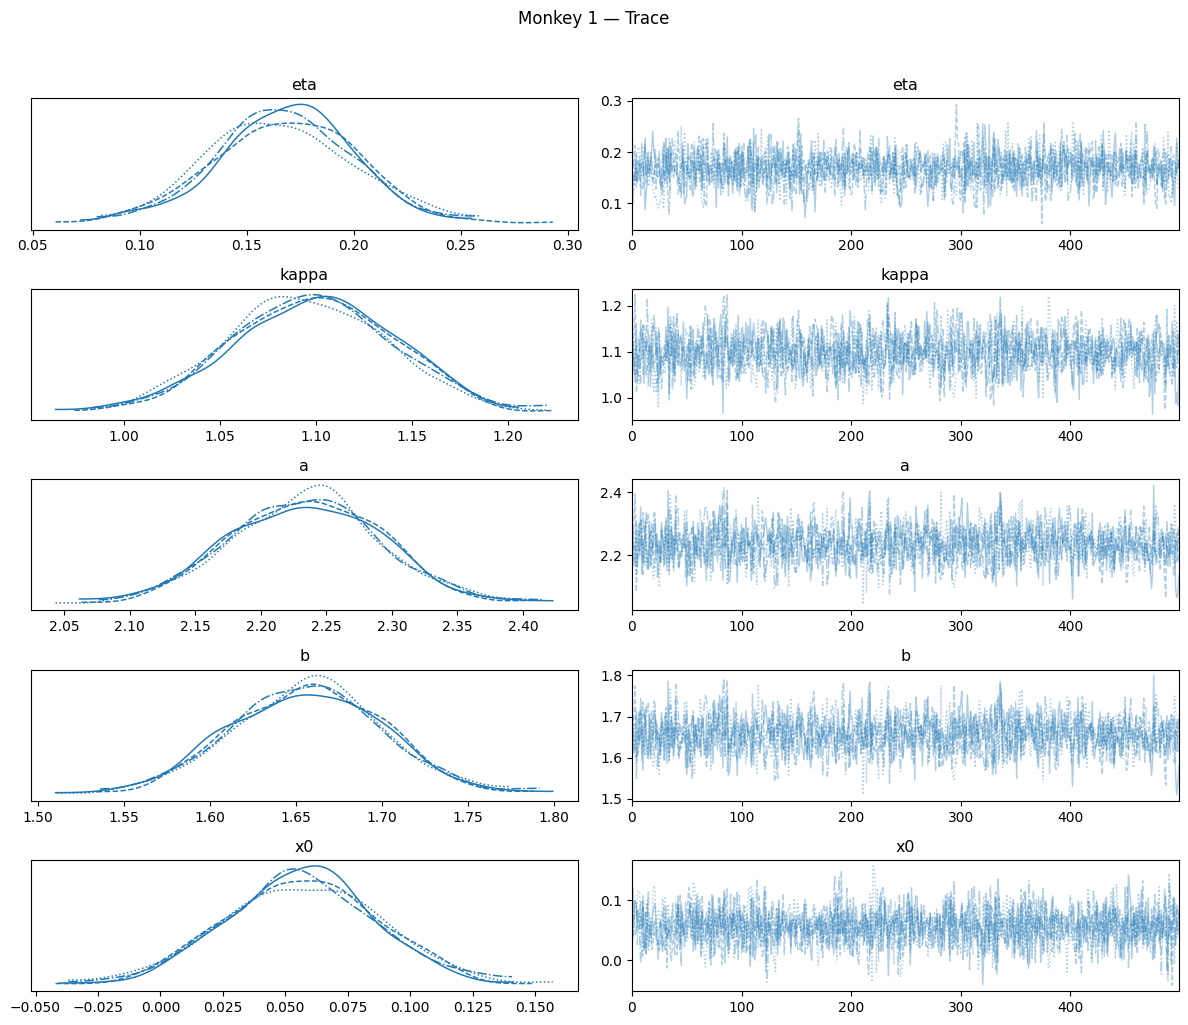

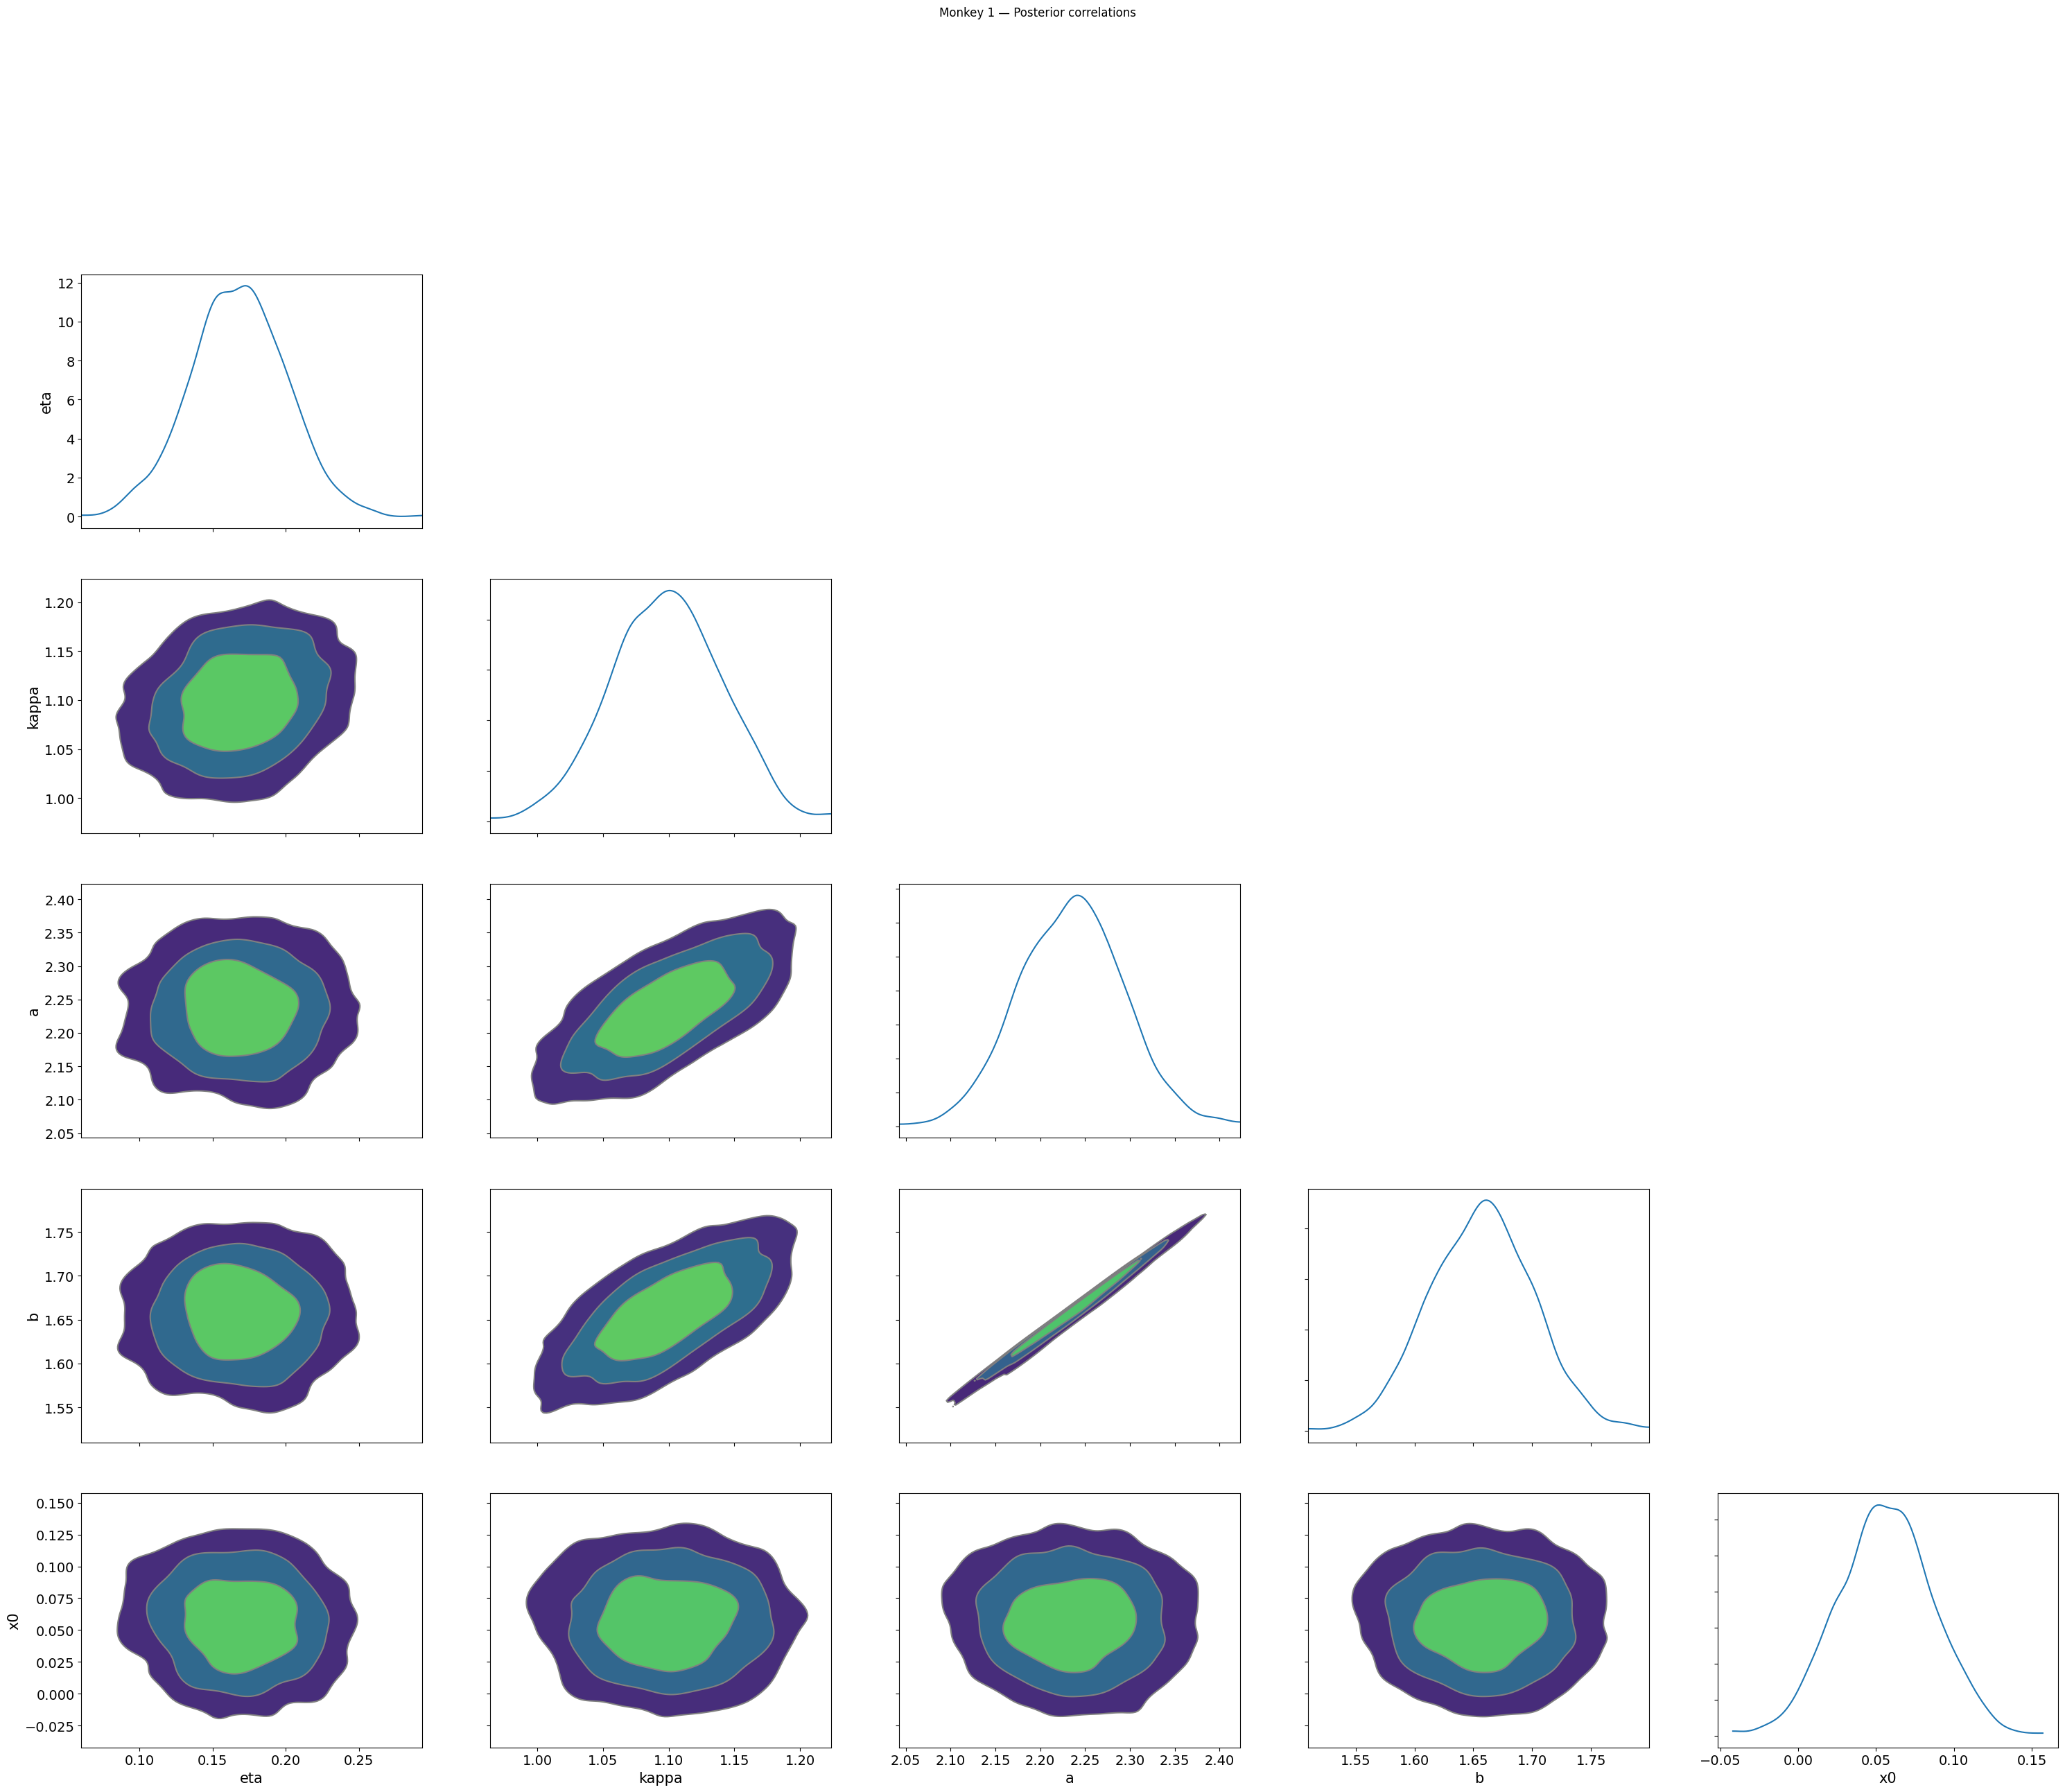

In [23]:
print("=== Monkey 1 Diagnostics ===")
print(az.summary(trace_1, var_names=params))

az.plot_trace(trace_1, var_names=params)
plt.suptitle("Monkey 1 — Trace", y=1.02)
plt.tight_layout()
plt.show()

az.plot_pair(trace_1, var_names=params, kind='kde', marginals=True)
plt.suptitle("Monkey 1 — Posterior correlations", y=1.02)
plt.show()

---
# Monkey 2

In [43]:
data_2     = preprocess_monkey_data(monk_data_2, max_d)
jax_data_2 = make_jax_arrays(data_2, max_d)

print(f"Monkey 2 | trials: {len(data_2['rt'])}, max RT: {data_2['rt'].max():.4f}")

Monkey 2 | trials: 607, max RT: 3.6460


In [45]:
loglik_2, grad_2 = make_jax_likelihood(jax_data_2, sigma, max_d, TRUNC_NUM)

print("Warming up JIT for Monkey 2...")
t0_ = time.time()
ll_test_2 = loglik_2(0.7, 0.5, 2.0, 0.3, -0.2)
_          = grad_2(0.7, 0.5, 2.0, 0.3, -0.2)
print(f"JIT warm-up: {time.time()-t0_:.1f}s  |  ll={float(ll_test_2):.4f}")

op_2    = LogLikeJAX(loglik_2, grad_2)
model_2 = make_pymc_model(op_2, float(np.max(data_2['rt'])))
print("Model 2 built.", model_2.point_logps())

Warming up JIT for Monkey 2...
JIT warm-up: 5.0s  |  ll=-1336.9636
Model 2 built. {'eta': np.float64(-0.98), 'kappa': np.float64(-0.61), 'a': np.float64(-0.25), 'b_raw': np.float64(-0.98), 'x0_raw': np.float64(-0.98), 'loglik': np.float64(-1335.45)}


In [46]:
print(f"Sampling Monkey 2 | {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model_2:
    t_start = time.perf_counter()
    trace_2 = pm.sample(
        draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
    )
    t_sample_2 = time.perf_counter() - t_start

print(f"Finished: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total: {t_sample_2:.1f}s")

Sampling Monkey 2 | 500 draws, 500 tune, 4 chains
Started: 13:58:06


Compiling.. :   0%|          | 0/1000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/1000 [00:09<?, ?it/s]


Running chain 0:   5%|▌         | 50/1000 [00:20<03:29,  4.54it/s]



Running chain 0:  10%|█         | 100/1000 [00:39<04:41,  3.20it/s]


Running chain 0:  20%|██        | 200/1000 [01:00<03:04,  4.34it/s]




Running chain 0:  30%|███       | 300/1000 [01:19<02:20,  4.97it/s]


Running chain 0:  40%|████      | 400/1000 [01:28<01:24,  7.07it/s]


Running chain 0:  45%|████▌     | 450/1000 [01:34<01:13,  7.45it/s]

Running chain 0:  50%|█████     | 500/1000 [01:44<01:19,  6.31it/s]




Running chain 0:  55%|█████▌    | 550/1000 [01:52<01:10,  6.40it/s]


Running chain 0:  60%|██████    | 600/1000 [02:00<01:03,  6.29it/s]

Running chain 0:  65%|██████▌   | 650/1000 [02:08<00:56,  6.20it/s]


Running chain 0:  70%|███████   | 700/1000 [02:16<00:46,  6.39it/s]


Running chain 0:  75%|███████▌  | 750/1000 [02:24<00:40,  6.23it/s]




Running chain 0:  80%|████████  | 80

Finished: 14:01:30
Total: 203.5s


=== Monkey 2 Diagnostics ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.417  0.036   0.348    0.482      0.001    0.001    1245.0    1148.0   
kappa  0.824  0.035   0.763    0.892      0.001    0.001     951.0    1084.0   
a      1.114  0.025   1.071    1.165      0.001    0.001     598.0     302.0   
b      0.201  0.010   0.182    0.217      0.000    0.000     508.0     270.0   
x0     0.031  0.025  -0.018    0.075      0.001    0.001     995.0    1003.0   

       r_hat  
eta     1.01  
kappa   1.00  
a       1.01  
b       1.01  
x0      1.00  


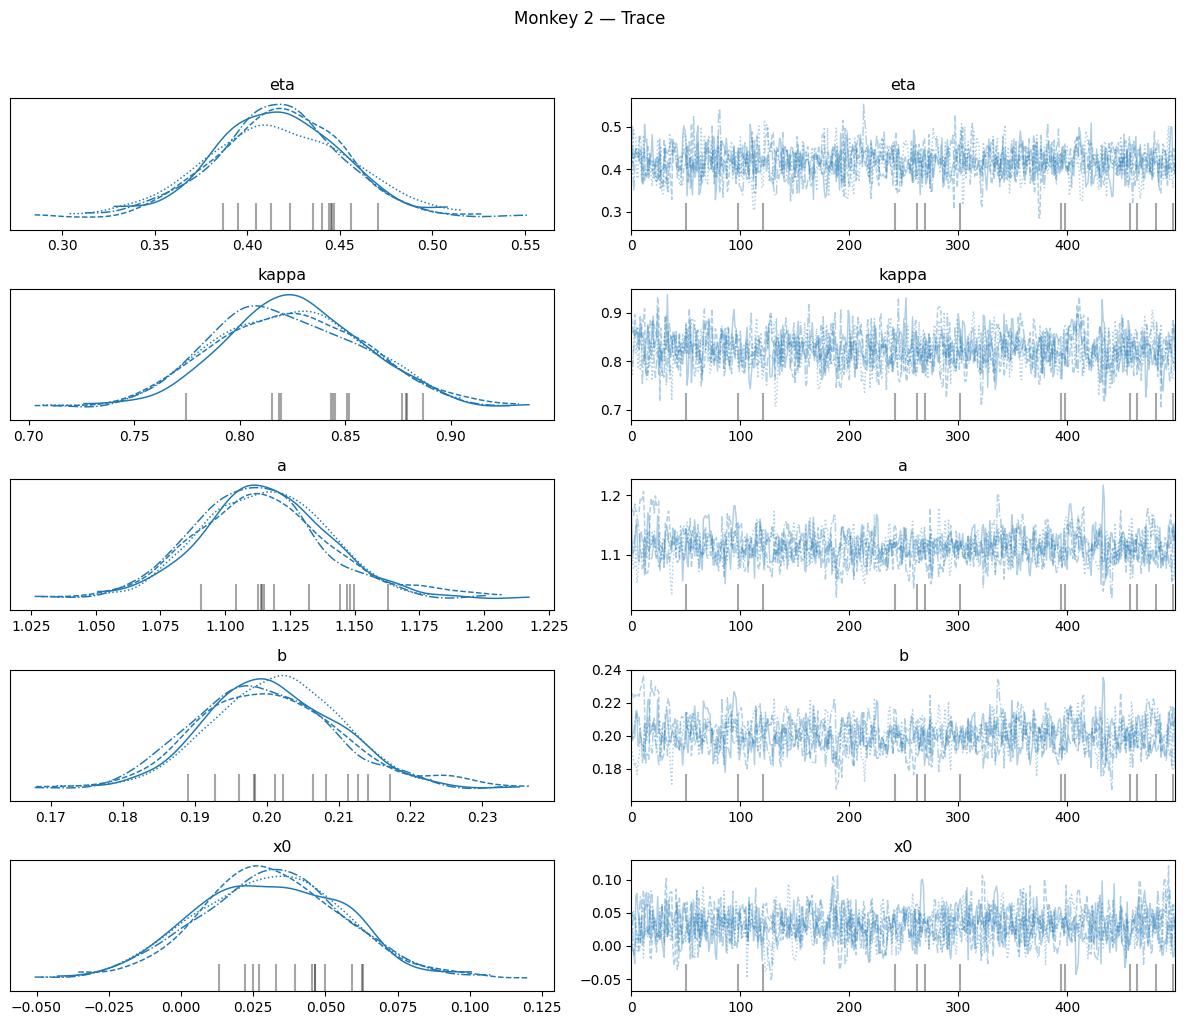

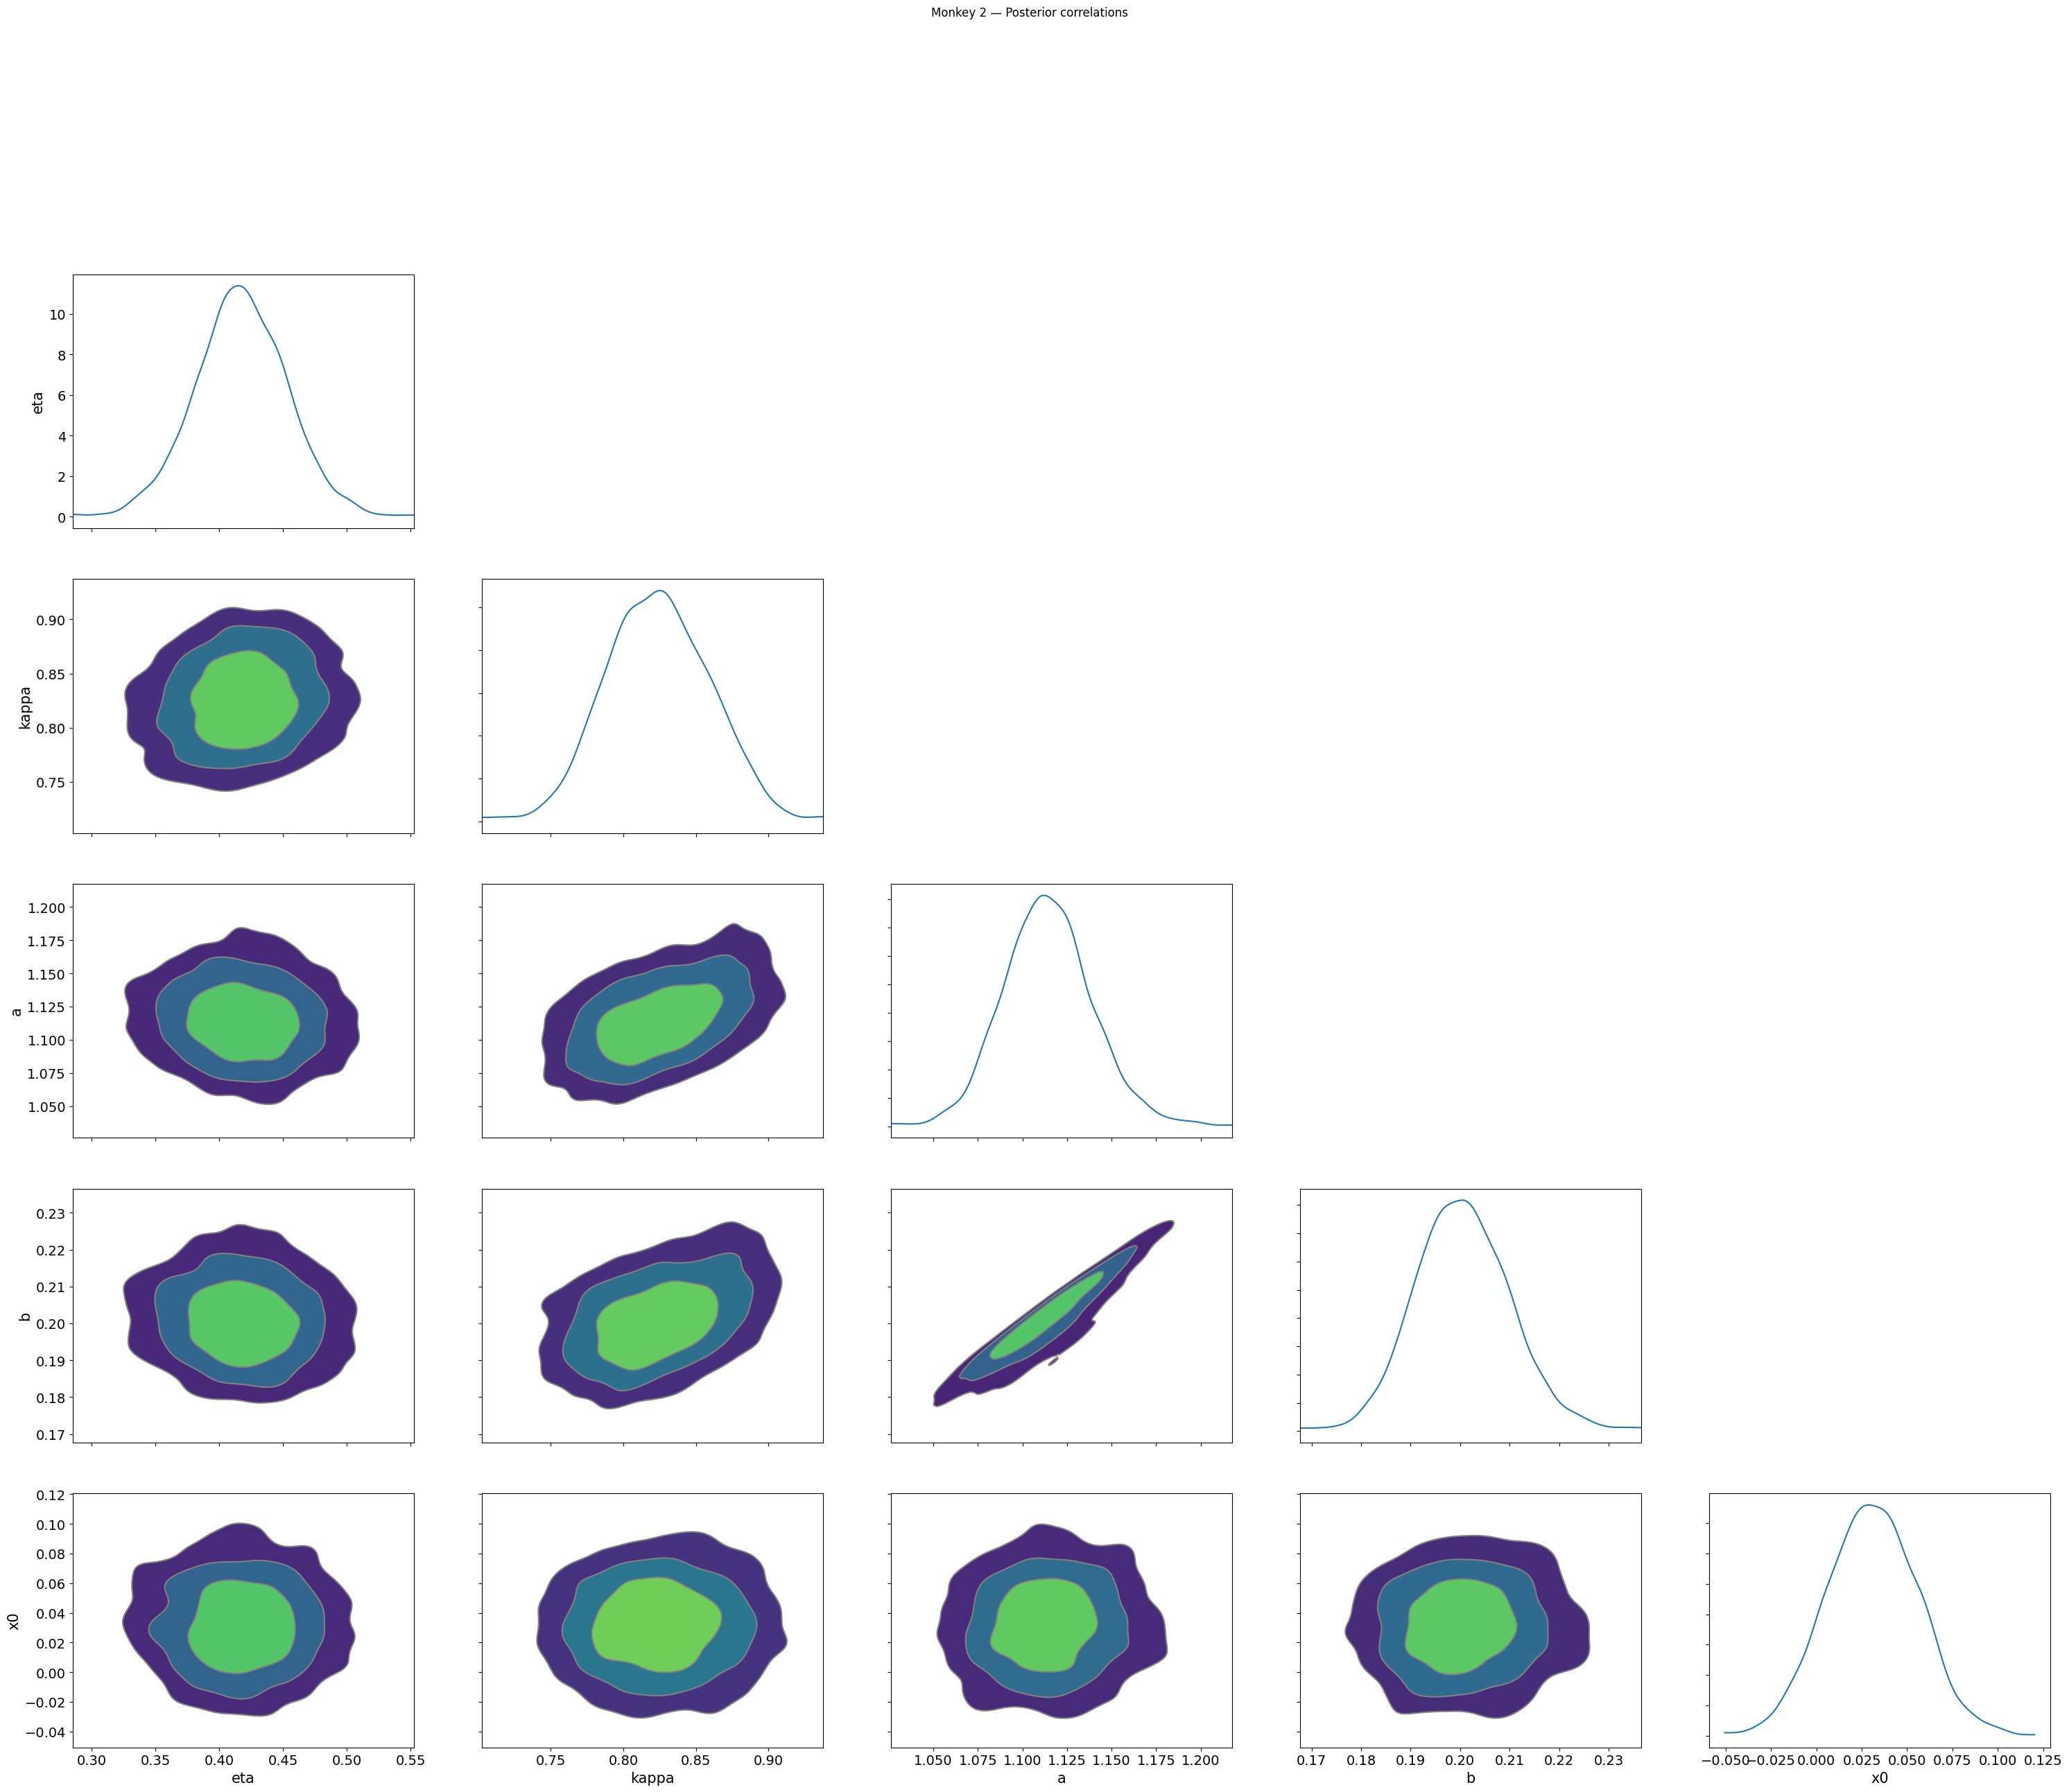

In [47]:
print("=== Monkey 2 Diagnostics ===")
print(az.summary(trace_2, var_names=params))

az.plot_trace(trace_2, var_names=params)
plt.suptitle("Monkey 2 — Trace", y=1.02)
plt.tight_layout()
plt.show()

az.plot_pair(trace_2, var_names=params, kind='kde', marginals=True)
plt.suptitle("Monkey 2 — Posterior correlations", y=1.02)
plt.show()

---
# Monkey 3

In [48]:
data_3     = preprocess_monkey_data(monk_data_3, max_d)
jax_data_3 = make_jax_arrays(data_3, max_d)

print(f"Monkey 3 | trials: {len(data_3['rt'])}, max RT: {data_3['rt'].max():.4f}")

Monkey 3 | trials: 606, max RT: 1.5633


In [49]:
loglik_3, grad_3 = make_jax_likelihood(jax_data_3, sigma, max_d, TRUNC_NUM)

print("Warming up JIT for Monkey 3...")
t0_ = time.time()
ll_test_3 = loglik_3(0.7, 0.5, 2.0, 0.3, -0.2)
_          = grad_3(0.7, 0.5, 2.0, 0.3, -0.2)
print(f"JIT warm-up: {time.time()-t0_:.1f}s  |  ll={float(ll_test_3):.4f}")

op_3    = LogLikeJAX(loglik_3, grad_3)
model_3 = make_pymc_model(op_3, float(np.max(data_3['rt'])))
print("Model 3 built.", model_3.point_logps())

Warming up JIT for Monkey 3...
JIT warm-up: 6.4s  |  ll=-1506.1502
Model 3 built. {'eta': np.float64(-0.98), 'kappa': np.float64(-0.61), 'a': np.float64(-0.25), 'b_raw': np.float64(-0.98), 'x0_raw': np.float64(-0.98), 'loglik': np.float64(-1073.76)}


In [50]:
print(f"Sampling Monkey 3 | {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model_3:
    t_start = time.perf_counter()
    trace_3 = pm.sample(
        draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
    )
    t_sample_3 = time.perf_counter() - t_start

print(f"Finished: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total: {t_sample_3:.1f}s")

Sampling Monkey 3 | 500 draws, 500 tune, 4 chains
Started: 14:01:40


Compiling.. :   0%|          | 0/1000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/1000 [00:10<?, ?it/s]





Running chain 0:   5%|▌         | 50/1000 [00:26<05:07,  3.09it/s]





Running chain 0:  10%|█         | 100/1000 [00:59<07:46,  1.93it/s]



Running chain 0:  15%|█▌        | 150/1000 [01:09<05:23,  2.63it/s]


Running chain 0:  20%|██        | 200/1000 [01:15<03:36,  3.69it/s]


Running chain 0:  25%|██▌       | 250/1000 [01:20<02:37,  4.76it/s]








Running chain 0:  30%|███       | 300/1000 [01:36<02:55,  4.00it/s]



Running chain 0:  40%|████      | 400/1000 [01:48<01:45,  5.68it/s]




Running chain 0:  45%|████▌     | 450/1000 [01:56<01:35,  5.78it/s]







Running chain 0:  50%|█████     | 500/1000 [02:05<01:28,  5.67it/s]


Running chain 2: 100%|██████████| 1000/1000 [02:10<00:00,  7.66it/s]


Running chain 0:  60%|██████    | 600/1000 [02:15<00:53,  7.41it/s]



Running chain 0:  65%|██████▌   | 650/1000 [02:20<00:43,  8.00it/s]

Running chain 0:  7

Finished: 14:04:41
Total: 181.2s


=== Monkey 3 Diagnostics ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.427  0.042   0.350    0.509      0.001    0.001    1116.0     709.0   
kappa  0.727  0.035   0.662    0.791      0.001    0.001     791.0    1086.0   
a      1.323  0.031   1.265    1.381      0.001    0.001     640.0     655.0   
b      0.758  0.022   0.717    0.798      0.001    0.001     585.0     627.0   
x0     0.035  0.026  -0.016    0.080      0.001    0.001    1153.0    1029.0   

       r_hat  
eta     1.01  
kappa   1.00  
a       1.01  
b       1.01  
x0      1.00  


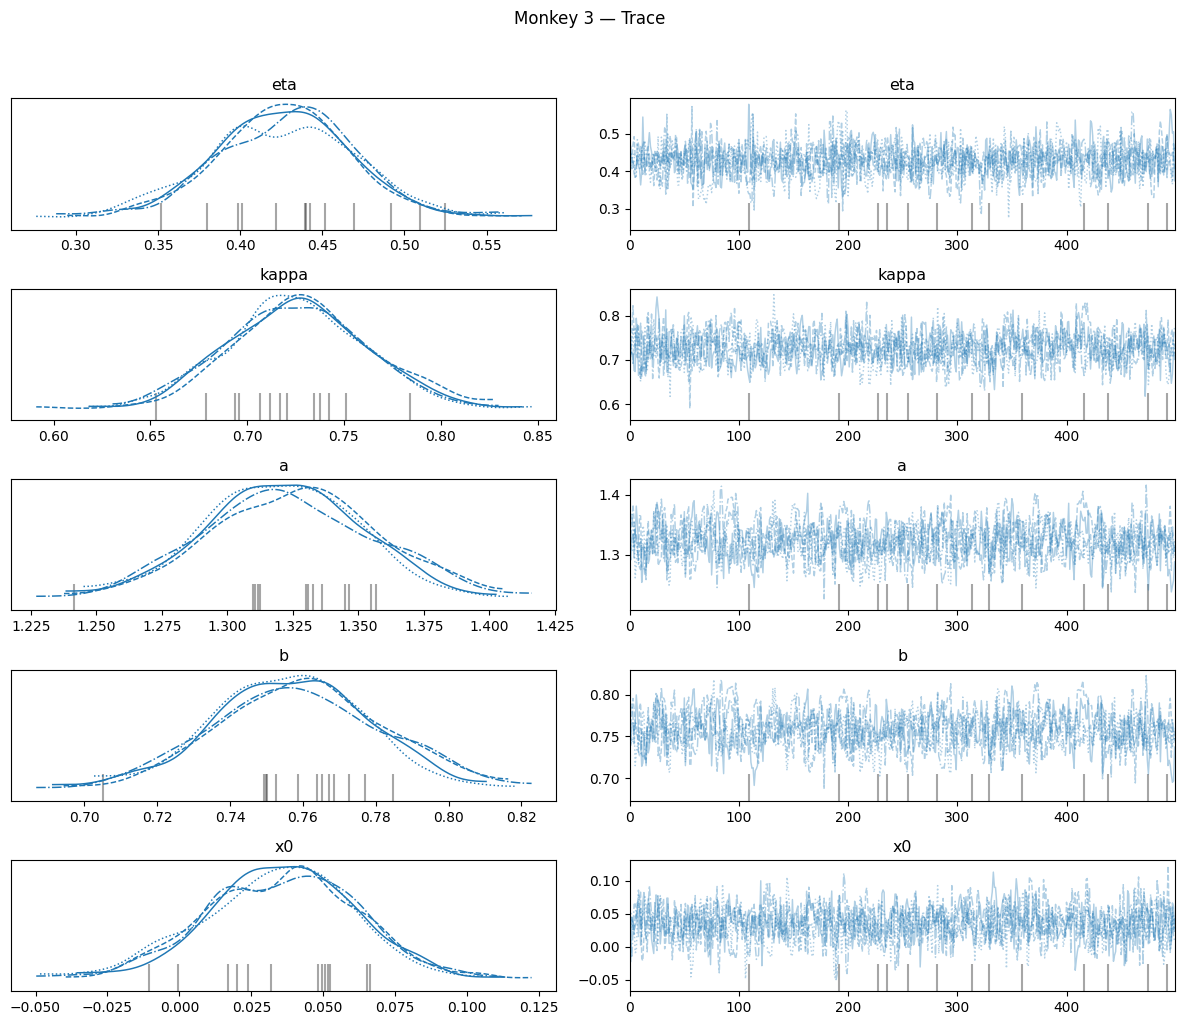

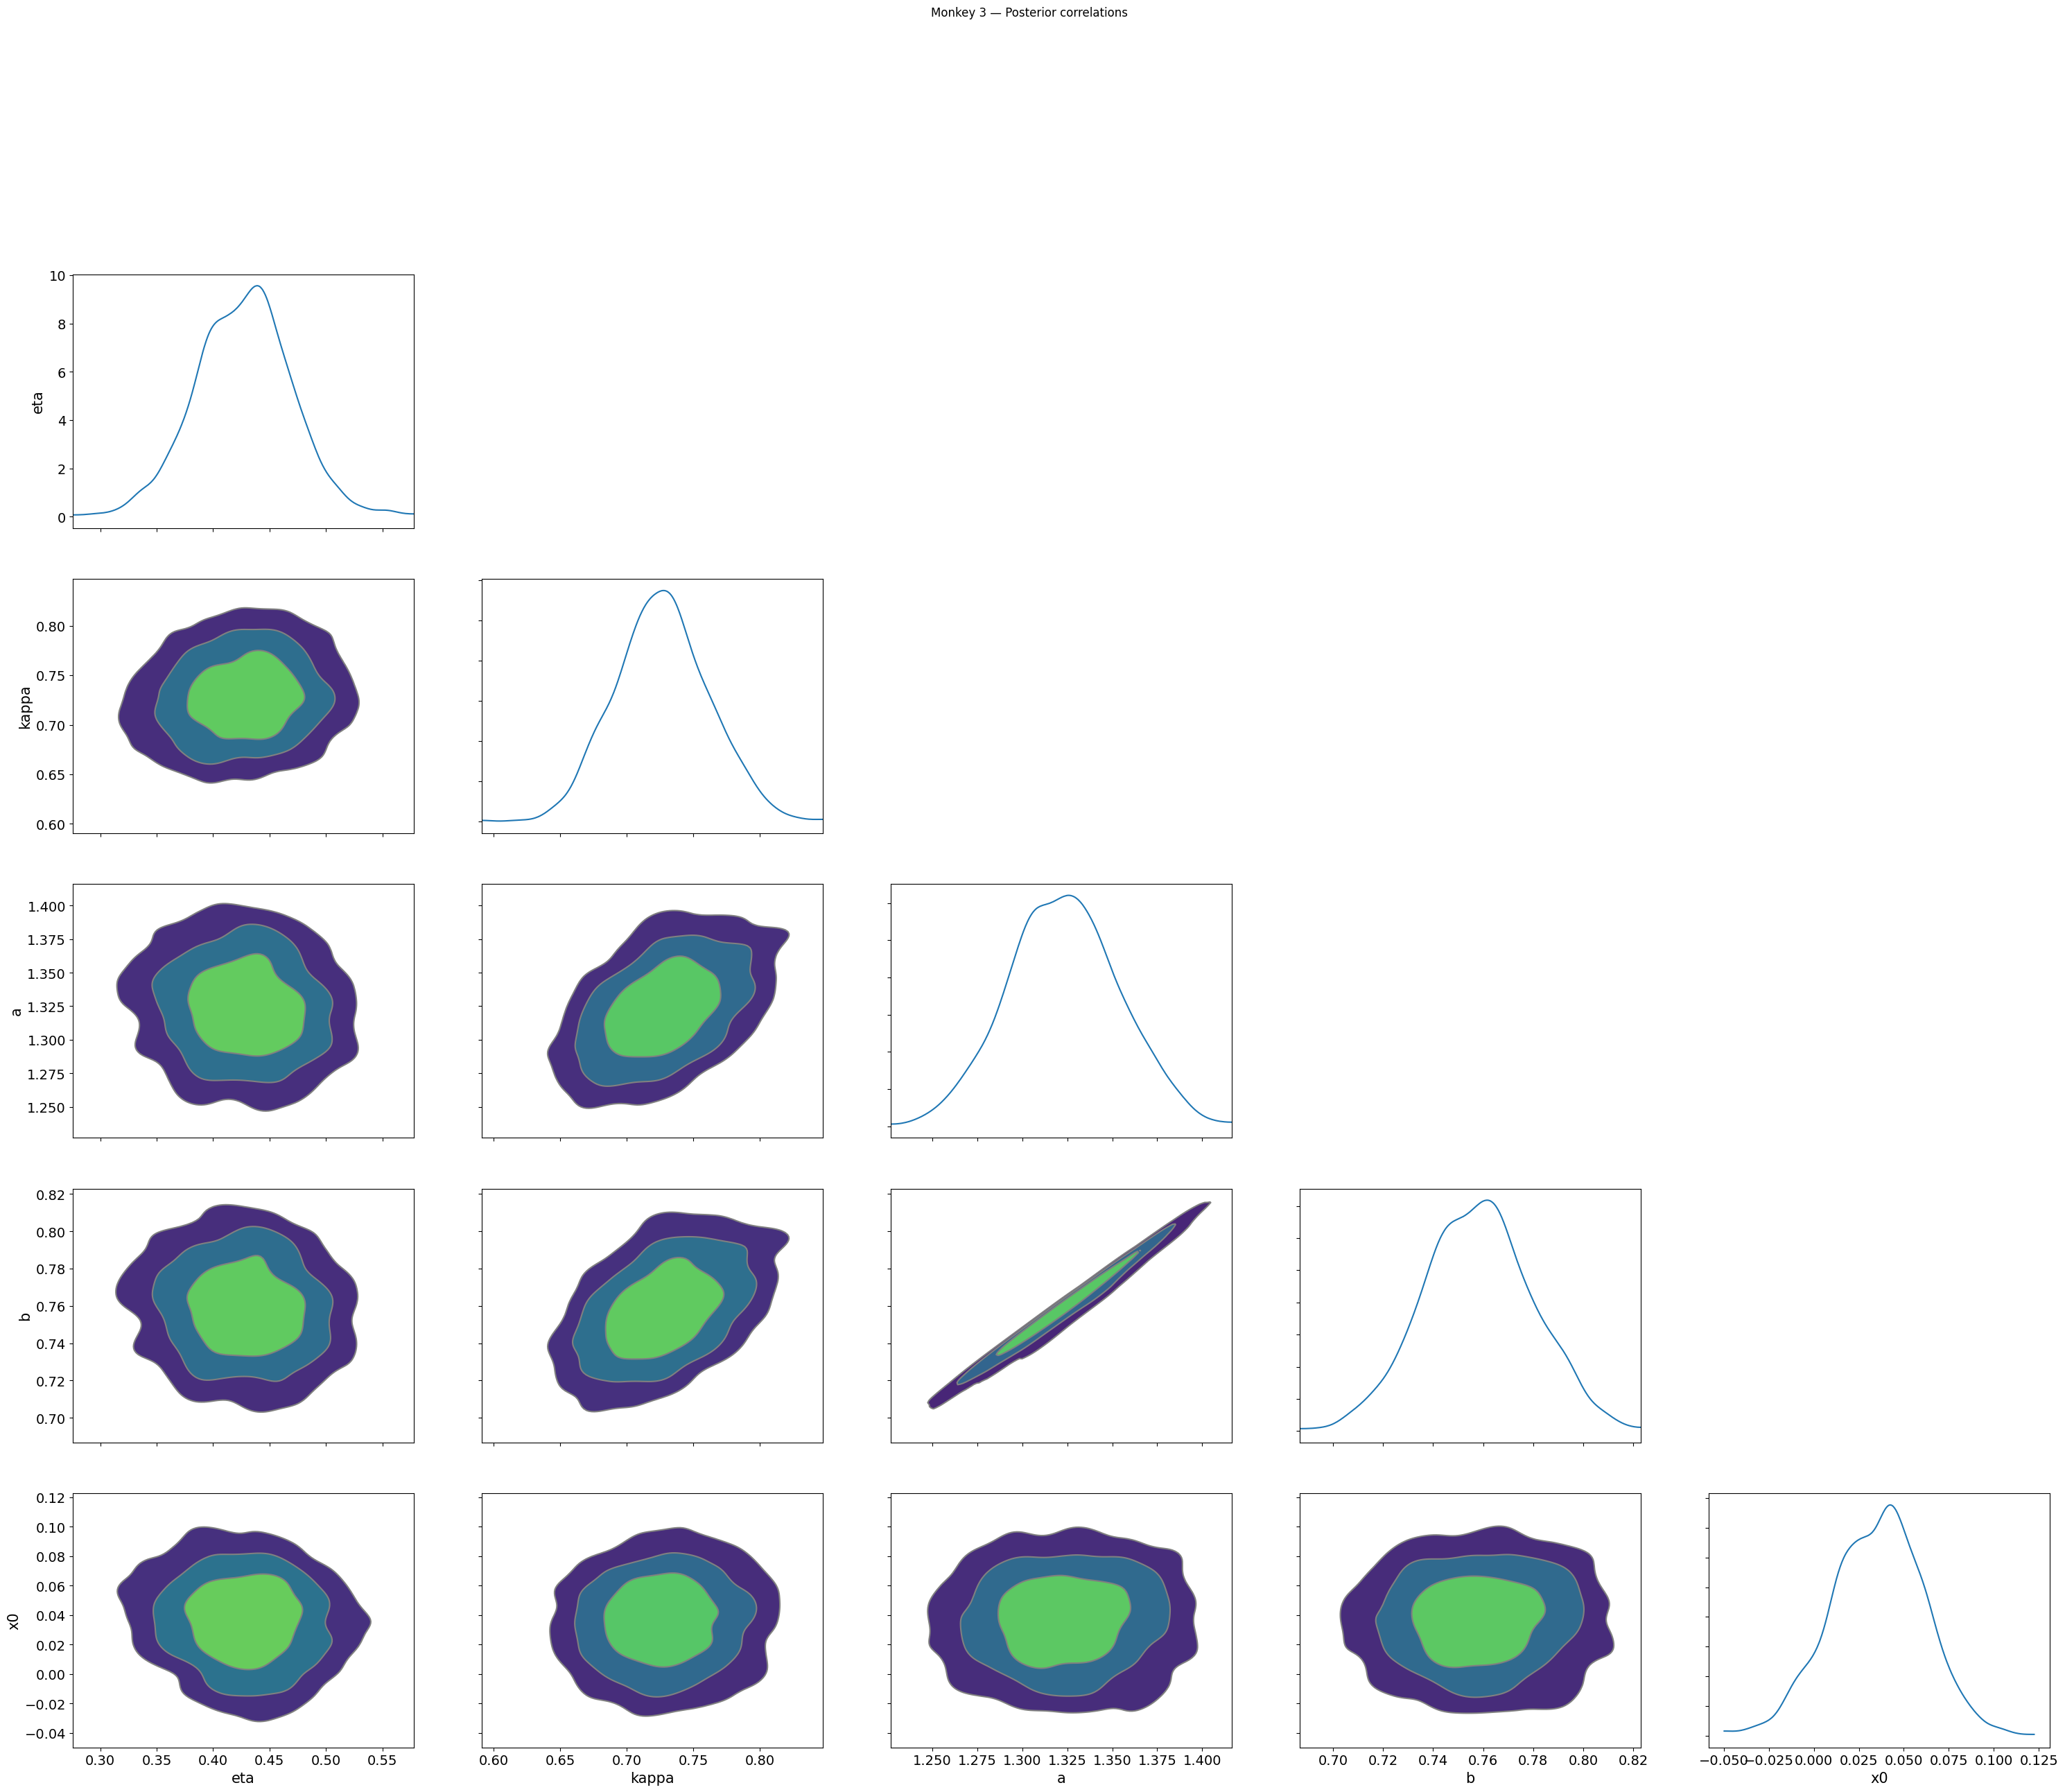

In [51]:
print("=== Monkey 3 Diagnostics ===")
print(az.summary(trace_3, var_names=params))

az.plot_trace(trace_3, var_names=params)
plt.suptitle("Monkey 3 — Trace", y=1.02)
plt.tight_layout()
plt.show()

az.plot_pair(trace_3, var_names=params, kind='kde', marginals=True)
plt.suptitle("Monkey 3 — Posterior correlations", y=1.02)
plt.show()

In [52]:
# save traces
# trace_1.to_netcdf("/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk1.nc") 
# trace_2.to_netcdf("/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk2.nc")
# trace_3.to_netcdf("/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk3.nc")

'/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk3.nc'

In [53]:
trace_1_res = az.from_netcdf("/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/trace_monk1.nc")

In [54]:
r1_m1 = data_1['r1']
r2_m1 = data_1['r2']
length_data_m1 = data_1['length_data']
flag_data_m1 = data_1['flag_data']
max_d = 4
sacc_m1 = data_1['sacc']

---
# Posterior Predictive

Drawing 500 posterior samples from 2000 total.
Unique lVal - rVal differences: [-4, -3, -2, -1, 0, 1, 2, 3, 4]
  diff = -4: 18 trials
  diff = -3: 37 trials
  diff = -2: 70 trials
  diff = -1: 117 trials
  diff = +0: 91 trials
  diff = +1: 118 trials
  diff = +2: 88 trials
  diff = +3: 31 trials
  diff = +4: 17 trials


  processed draw 20/500
  processed draw 40/500
  processed draw 60/500
  processed draw 80/500
  processed draw 100/500
  processed draw 120/500
  processed draw 140/500
  processed draw 160/500
  processed draw 180/500
  processed draw 200/500
  processed draw 220/500
  processed draw 240/500
  processed draw 260/500
  processed draw 280/500
  processed draw 300/500
  processed draw 320/500
  processed draw 340/500
  processed draw 360/500
  processed draw 380/500
  processed draw 400/500
  processed draw 420/500
  processed draw 440/500
  processed draw 460/500
  processed draw 480/500
  processed draw 500/500


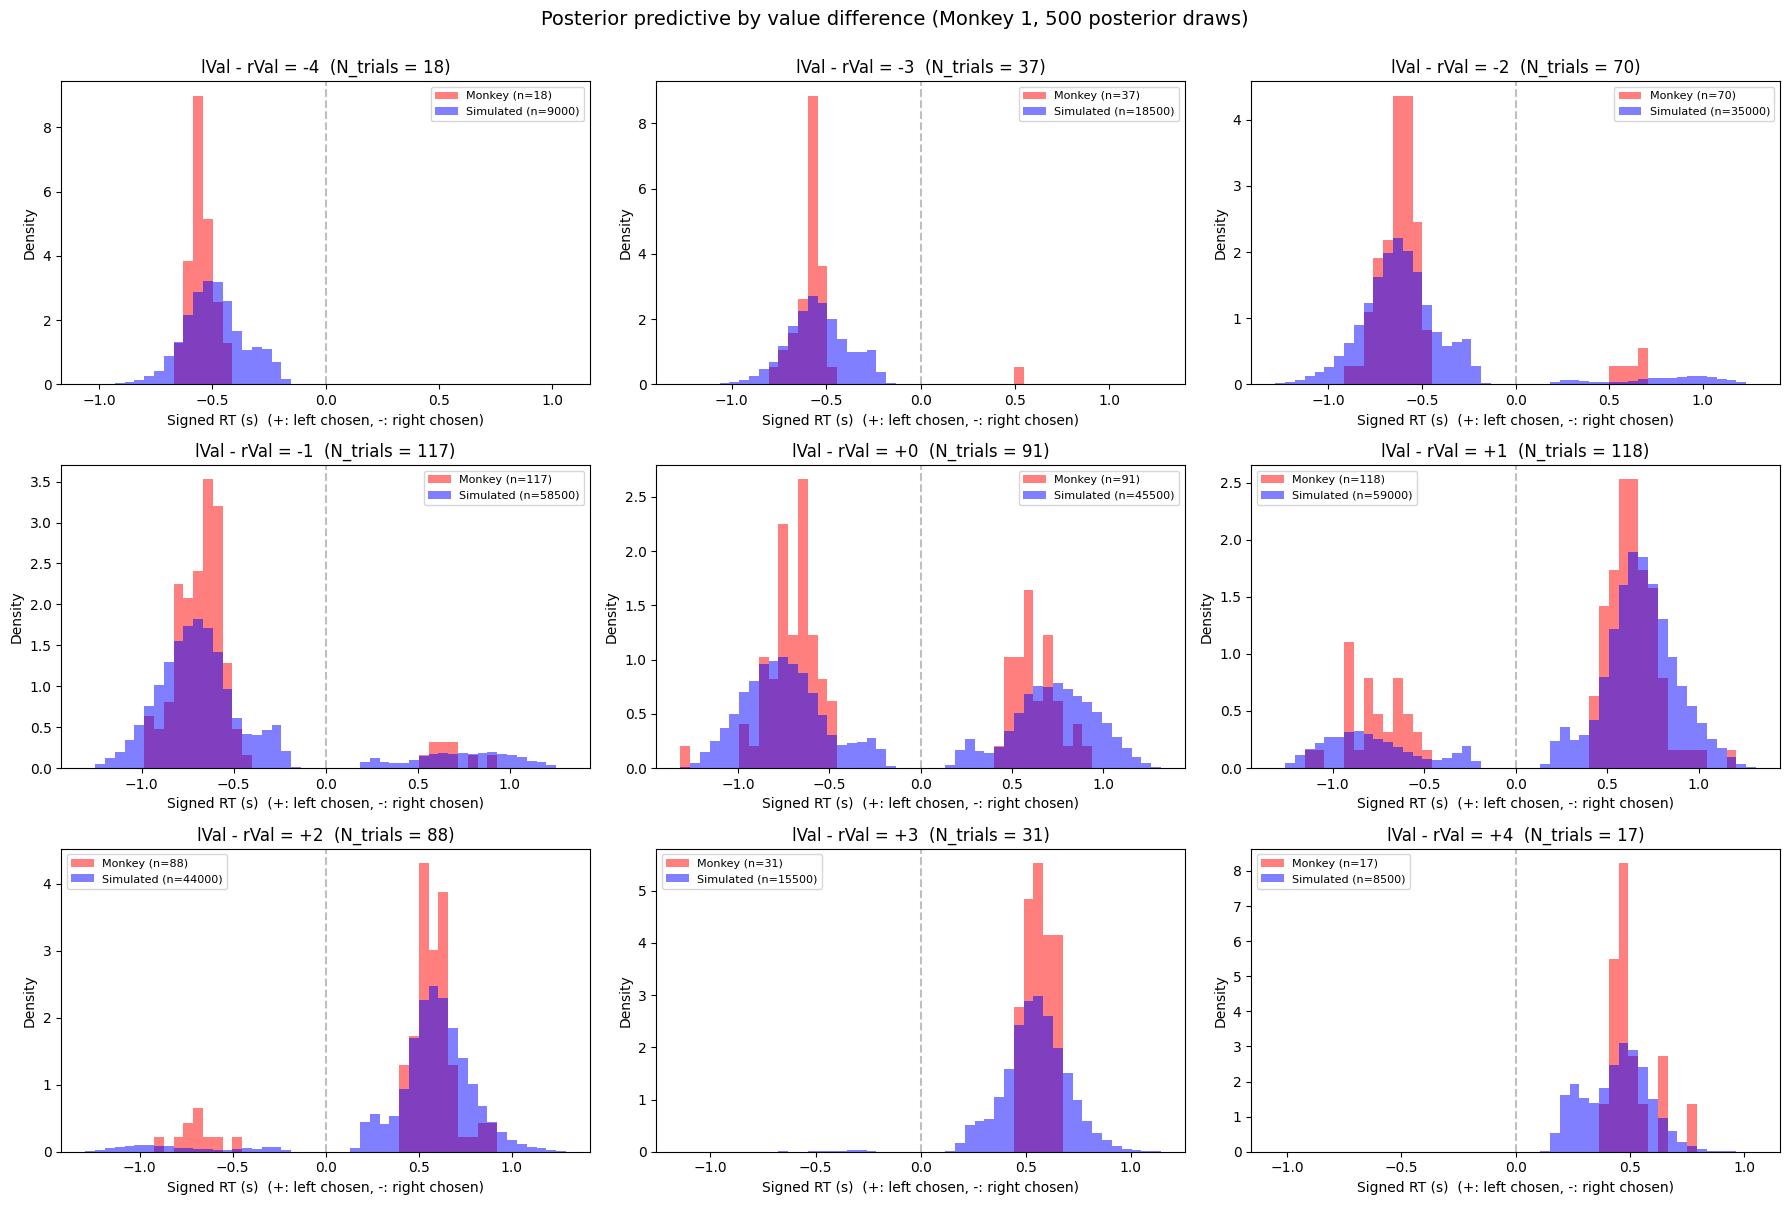


Per-bin summary:
 diff  n_trials  emp_mean_rt  sim_mean_rt  emp_p_left  sim_p_left
   -4        18       0.5469       0.4891      0.0000      0.0009
   -3        37       0.5876       0.5453      0.0270      0.0129
   -2        70       0.6290       0.6342      0.0714      0.0775
   -1       117       0.6859       0.7036      0.0769      0.1378
    0        91       0.6775       0.7381      0.3846      0.4475
    1       118       0.6720       0.7027      0.7373      0.8080
    2        88       0.5949       0.6107      0.8864      0.9403
    3        31       0.5649       0.5487      1.0000      0.9939
    4        17       0.5076       0.4409      1.0000      0.9994


In [ ]:
# Posterior predictive stratified by (lVal - rVal) difference
# Simulates from N_PPC_DRAWS posterior samples (not just the mean) for each difference bin.

from efficient_fpt.addm import _build_mu_data_padded
from efficient_fpt.addm_simulator_cy import simulate_addm_batch_cy
from scipy.stats import gaussian_kde

# ---- config ----
def plot_ppc_by_diff(trace, data):
    N_PPC_DRAWS = 500            # number of posterior draws to simulate from
    PLOT_KIND   = 'hist'          # 'kde' or 'hist' (KDE is default; histogram available)
    PPC_SEED    = 2024
    dt          = 1e-4
    max_t       = 10.0
    sigma       = 1.0

    # Flatten posterior (chains x draws) and sample
    post = trace.posterior
    eta_s   = post['eta'].values.reshape(-1)
    kappa_s = post['kappa'].values.reshape(-1)
    a_s     = post['a'].values.reshape(-1)
    b_s     = post['b'].values.reshape(-1)
    x0_s    = post['x0'].values.reshape(-1)
    r1 = data['r1']
    r2 = data['r2']
    length_data = data['length_data']
    flag_data = data['flag_data']
    sacc = data['sacc']

    rng_pick = np.random.default_rng(PPC_SEED)
    n_post = eta_s.size
    draw_idx = rng_pick.choice(n_post, size=min(N_PPC_DRAWS, n_post), replace=False)
    print(f"Drawing {len(draw_idx)} posterior samples from {n_post} total.")

    # Difference bins
    diffs = (r1 - r2).astype(int)
    unique_diffs = np.sort(np.unique(diffs))
    print(f"Unique lVal - rVal differences: {unique_diffs.tolist()}")
    for d in unique_diffs:
        print(f"  diff = {d:+d}: {(diffs == d).sum()} trials")

    emp_rt_all     = data['rt']
    emp_choice_all = data['choice']

    # Gather simulated signed RTs per bin across draws
    sim_by_bin = {int(d): [] for d in unique_diffs}
    rng_sim = np.random.default_rng(PPC_SEED + 1)

    for k, idx in enumerate(draw_idx):
        eta_k, kappa_k = float(eta_s[idx]), float(kappa_s[idx])
        a_k, b_k, x0_k = float(a_s[idx]), float(b_s[idx]), float(x0_s[idx])

        mu1_k = kappa_k * (r1 - eta_k * r2)
        mu2_k = kappa_k * (eta_k * r1 - r2)
        mu_data_k = _build_mu_data_padded(
            mu1_k.astype(np.float64), mu2_k.astype(np.float64),
            length_data, flag_data, max_d,
        )

        budget_time_k  = min(a_k / b_k, max_t) if b_k > 0 else max_t
        budget_steps_k = int(budget_time_k / dt) + 1

        for d in unique_diffs:
            mask = diffs == d
            n_bin = int(mask.sum())
            if n_bin == 0:
                continue
            sub_mu    = np.ascontiguousarray(mu_data_k[mask])
            sub_sacc  = np.ascontiguousarray(sacc[mask])
            sub_len   = np.ascontiguousarray(length_data[mask])
            gnoise    = np.ascontiguousarray(
                rng_sim.standard_normal((n_bin, budget_steps_k), dtype=np.float64)
            )
            sim_rt_k, sim_ch_k = simulate_addm_batch_cy(
                sub_mu, sub_sacc, sub_len,
                sigma, a_k, b_k, x0_k, dt, budget_time_k, gnoise,
            )
            sim_rt_k = np.array(sim_rt_k); sim_ch_k = np.array(sim_ch_k)
            ok = sim_rt_k > 0
            sim_by_bin[int(d)].append(sim_rt_k[ok] * sim_ch_k[ok])

        if (k + 1) % 20 == 0 or k + 1 == len(draw_idx):
            print(f"  processed draw {k+1}/{len(draw_idx)}")

    # Concatenate per-bin across draws
    sim_by_bin_concat = {d: (np.concatenate(v) if len(v) else np.array([]))
                        for d, v in sim_by_bin.items()}

    # ---- plotting ----
    n_bins_plot = len(unique_diffs)
    n_cols = 3
    n_rows = int(np.ceil(n_bins_plot / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    summary_rows = []

    for ax, d in zip(axes, unique_diffs):
        mask = diffs == d
        n_trials_bin = int(mask.sum())

        emp_mask = mask & (emp_rt_all > 0)
        emp_signed = emp_rt_all[emp_mask] * emp_choice_all[emp_mask]
        sim_signed = sim_by_bin_concat[int(d)]

        # Shared range for this bin
        pool = np.concatenate([emp_signed, sim_signed]) if len(sim_signed) else emp_signed
        lim = np.abs(pool).max() if len(pool) else 1.0
        x_grid = np.linspace(-lim, lim, 400)

        if PLOT_KIND == 'hist':
            bins = np.linspace(-lim, lim, 50)
            ax.hist(emp_signed, bins=bins, density=True, alpha=0.5, color='red',
                    label=f'Monkey (n={len(emp_signed)})')
            ax.hist(sim_signed, bins=bins, density=True, alpha=0.5, color='blue',
                    label=f'Simulated (n={len(sim_signed)})')
        else:  # kde
            if len(emp_signed) > 1:
                emp_kde = gaussian_kde(emp_signed)
                ax.plot(x_grid, emp_kde(x_grid), color='red', lw=2,
                        label=f'Monkey (n={len(emp_signed)})')
                ax.fill_between(x_grid, emp_kde(x_grid), color='red', alpha=0.2)
            if len(sim_signed) > 1:
                sim_kde = gaussian_kde(sim_signed)
                ax.plot(x_grid, sim_kde(x_grid), color='blue', lw=2,
                        label=f'Simulated (n={len(sim_signed)})')
                ax.fill_between(x_grid, sim_kde(x_grid), color='blue', alpha=0.2)

        ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(f'lVal - rVal = {d:+d}  (N_trials = {n_trials_bin})')
        ax.set_xlabel('Signed RT (s)  (+: left chosen, -: right chosen)')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

        summary_rows.append({
            'diff': int(d),
            'n_trials': n_trials_bin,
            'emp_mean_rt': float(np.mean(np.abs(emp_signed))) if len(emp_signed) else np.nan,
            'sim_mean_rt': float(np.mean(np.abs(sim_signed))) if len(sim_signed) else np.nan,
            'emp_p_left':  float((emp_signed > 0).mean())    if len(emp_signed) else np.nan,
            'sim_p_left':  float((sim_signed > 0).mean())    if len(sim_signed) else np.nan,
        })

    for ax in axes[len(unique_diffs):]:
        ax.axis('off')

    plt.suptitle(f'Posterior predictive by value difference (Monkey 1, {len(draw_idx)} posterior draws)',
                y=1.00, fontsize=14)
    plt.tight_layout()
    plt.show()

    summary_df = pd.DataFrame(summary_rows)
    print("\nPer-bin summary:")
    print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
plot_ppc_by_diff(trace_1, data_1)
# plot_ppc_by_diff(trace_2, data_2)
# plot_ppc_by_diff(trace_3, data_3)


Drawing 500 posterior samples from 2000 total.
Unique lVal - rVal differences: [-4, -3, -2, -1, 0, 1, 2, 3, 4]
  diff = -4: 12 trials
  diff = -3: 44 trials
  diff = -2: 82 trials
  diff = -1: 113 trials
  diff = +0: 97 trials
  diff = +1: 101 trials
  diff = +2: 95 trials
  diff = +3: 44 trials
  diff = +4: 19 trials
  processed draw 20/500
  processed draw 40/500
  processed draw 60/500
  processed draw 80/500
  processed draw 100/500
  processed draw 120/500
  processed draw 140/500
  processed draw 160/500
  processed draw 180/500
  processed draw 200/500
  processed draw 220/500
  processed draw 240/500
  processed draw 260/500
  processed draw 280/500
  processed draw 300/500
  processed draw 320/500
  processed draw 340/500
  processed draw 360/500
  processed draw 380/500
  processed draw 400/500
  processed draw 420/500
  processed draw 440/500
  processed draw 460/500
  processed draw 480/500
  processed draw 500/500


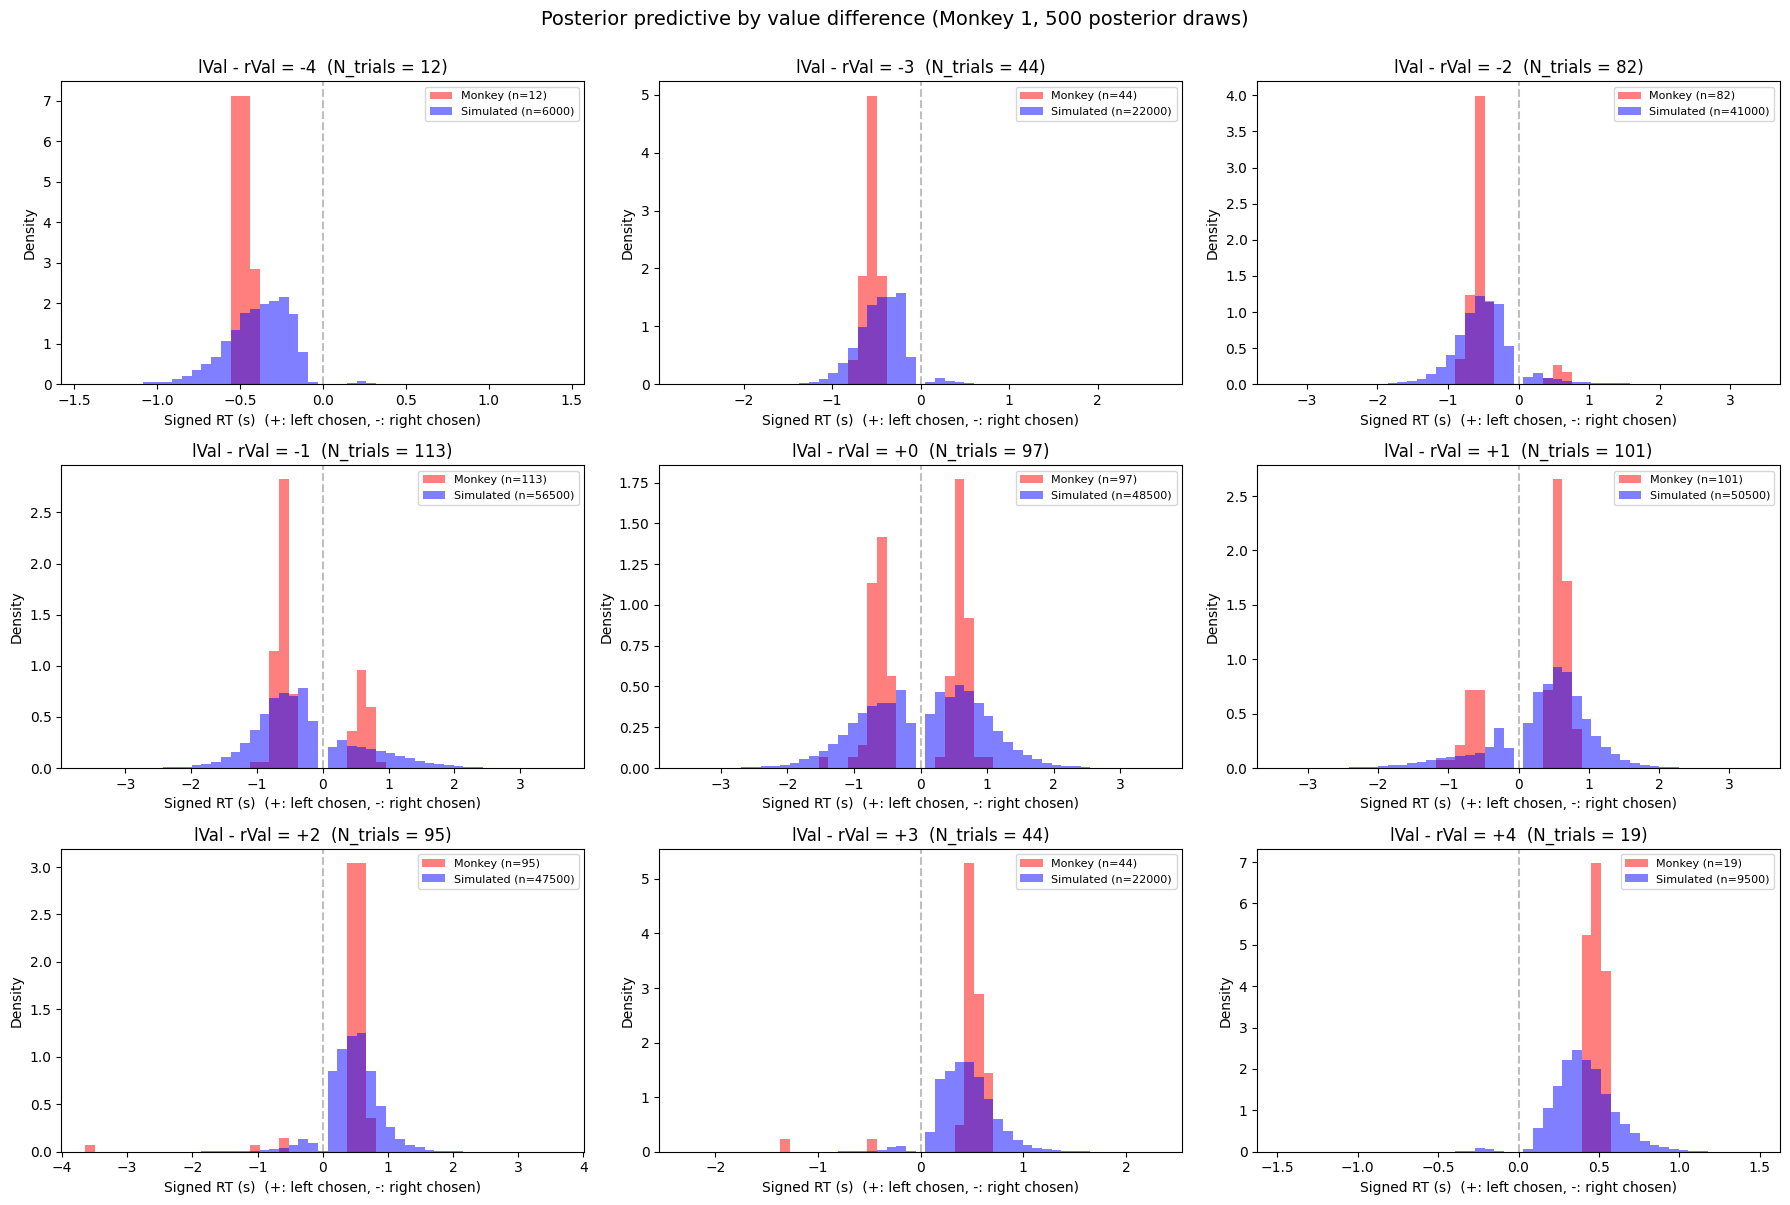


Per-bin summary:
 diff  n_trials  emp_mean_rt  sim_mean_rt  emp_p_left  sim_p_left
   -4        12       0.4878       0.3939      0.0000      0.0100
   -3        44       0.5610       0.4734      0.0000      0.0313
   -2        82       0.5622       0.5854      0.0732      0.0868
   -1       113       0.6133       0.7085      0.2920      0.2698
    0        97       0.6243       0.7480      0.5052      0.5317
    1       101       0.6117       0.6803      0.7525      0.7780
    2        95       0.5740       0.5493      0.9579      0.9356
    3        44       0.5411       0.4682      0.9545      0.9724
    4        19       0.4801       0.4162      1.0000      0.9875


In [59]:
plot_ppc_by_diff(trace_2, data_2)

Drawing 500 posterior samples from 2000 total.
Unique lVal - rVal differences: [-4, -3, -2, -1, 0, 1, 2, 3, 4]
  diff = -4: 22 trials
  diff = -3: 30 trials
  diff = -2: 83 trials
  diff = -1: 103 trials
  diff = +0: 92 trials
  diff = +1: 120 trials
  diff = +2: 109 trials
  diff = +3: 28 trials
  diff = +4: 19 trials
  processed draw 20/500
  processed draw 40/500
  processed draw 60/500
  processed draw 80/500
  processed draw 100/500
  processed draw 120/500
  processed draw 140/500
  processed draw 160/500
  processed draw 180/500
  processed draw 200/500
  processed draw 220/500
  processed draw 240/500
  processed draw 260/500
  processed draw 280/500
  processed draw 300/500
  processed draw 320/500
  processed draw 340/500
  processed draw 360/500
  processed draw 380/500
  processed draw 400/500
  processed draw 420/500
  processed draw 440/500
  processed draw 460/500
  processed draw 480/500
  processed draw 500/500


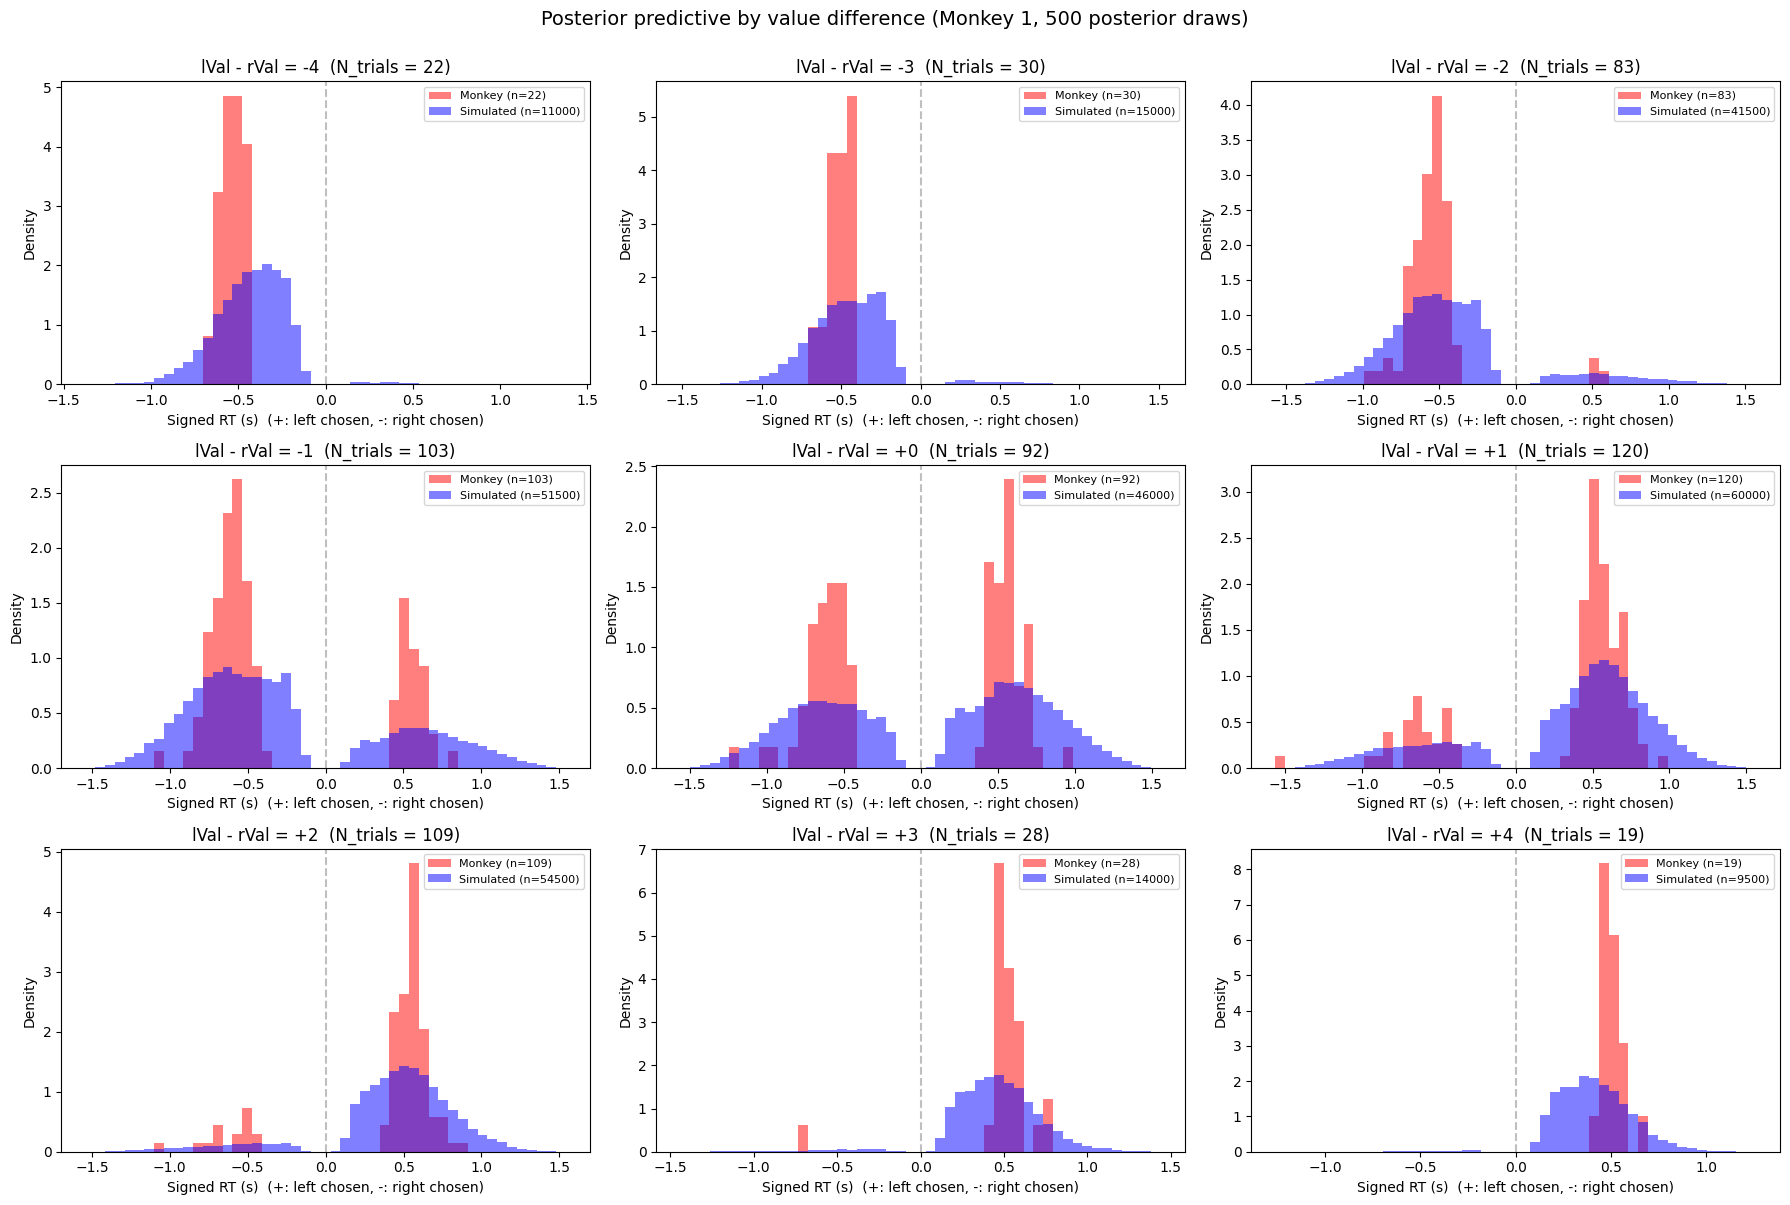


Per-bin summary:
 diff  n_trials  emp_mean_rt  sim_mean_rt  emp_p_left  sim_p_left
   -4        22       0.5342       0.4394      0.0000      0.0169
   -3        30       0.5137       0.4757      0.0000      0.0355
   -2        83       0.5719       0.5611      0.0361      0.1181
   -1       103       0.5995       0.6277      0.2913      0.2877
    0        92       0.5961       0.6484      0.5109      0.5445
    1       120       0.5878       0.6181      0.7667      0.7617
    2       109       0.5641       0.5593      0.8624      0.8948
    3        28       0.5428       0.4835      0.9643      0.9654
    4        19       0.5079       0.4232      1.0000      0.9880


In [60]:
plot_ppc_by_diff(trace_3, data_3)